In [101]:
#1: Import bibliotek i konfiguracja

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn. ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
import os
warnings.filterwarnings('ignore')

plt.style. use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Biblioteki załadowane pomyślnie")

Biblioteki załadowane pomyślnie


In [102]:
#2: Wczytanie danych

print("=" * 80)
print("WCZYTYWANIE DANYCH")
print("=" * 80)

df = pd.read_csv('housing_prices.csv')

if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("Kolumna 'id' została usunięta z analizy")

df['price_k_pln'] = df['price_pln'] / 1000
df = df.drop('price_pln', axis=1)

print(f"\nŹródło danych: housing_prices.csv")
print(f"Wymiary zbioru danych: {df.shape[0]} wierszy, {df.shape[1]} kolumn")
print(f"Kolumny: {list(df.columns)}")

WCZYTYWANIE DANYCH
Kolumna 'id' została usunięta z analizy

Źródło danych: housing_prices.csv
Wymiary zbioru danych: 220 wierszy, 6 kolumn
Kolumny: ['area_m2', 'distance_to_center_km', 'floor', 'building_age_years', 'high_standard', 'price_k_pln']


In [103]:
# 3: Podstawowe informacje o danych

print("\n" + "=" * 80)
print("PIERWSZE 10 WIERSZY DANYCH")
print("=" * 80)
print(df.head(10))


PIERWSZE 10 WIERSZY DANYCH
   area_m2  distance_to_center_km  floor  building_age_years  high_standard  \
0     59.4                   3.15      1                  43              0   
1     36.0                   4.24      4                  57              1   
2     68.0                   3.99      0                  46              0   
3     80.8                  15.70      0                  48              0   
4     18.0                   1.85      3                  46              1   
5     28.7                   0.99      2                  41              1   
6     57.4                   4.66      6                   3              0   
7     47.3                   2.07      0                  37              0   
8     51.4                   0.40      3                  25              1   
9     37.2                   1.52      4                  12              1   

   price_k_pln  
0      624.403  
1      618.779  
2      908.643  
3      466.647  
4      531.117  


In [104]:
# 4: Struktura danych

print("\n" + "=" * 80)
print("STRUKTURA DANYCH")
print("=" * 80)
df.info()


STRUKTURA DANYCH
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area_m2                220 non-null    float64
 1   distance_to_center_km  220 non-null    float64
 2   floor                  220 non-null    int64  
 3   building_age_years     220 non-null    int64  
 4   high_standard          220 non-null    int64  
 5   price_k_pln            220 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 10.4 KB


In [105]:
# 5: Statystyki opisowe

print("\n" + "=" * 80)
print("STATYSTYKI OPISOWE")
print("=" * 80)
print(df.describe())


STATYSTYKI OPISOWE
          area_m2  distance_to_center_km       floor  building_age_years  \
count  220.000000             220.000000  220.000000          220.000000   
mean    54.355909               4.559818    4.722727           34.818182   
std     16.089113               3.128682    3.237964           17.314803   
min     18.000000               0.300000    0.000000            0.000000   
25%     43.350000               2.382500    2.000000           24.000000   
50%     54.000000               3.990000    4.500000           35.500000   
75%     64.550000               6.042500    8.000000           44.000000   
max    106.200000              18.000000   10.000000           92.000000   

       high_standard  price_k_pln  
count     220.000000   220.000000  
mean        0.390909   720.437123  
std         0.489067   242.502883  
min         0.000000   140.000000  
25%         0.000000   558.458500  
50%         0.000000   696.342000  
75%         1.000000   872.521500  
max    

In [106]:
# 6: Analiza braków danych

print("\n" + "=" * 80)
print("ANALIZA BRAKÓW DANYCH")
print("=" * 80)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Braki': missing,
    'Procent': missing_pct
})

if missing. sum() > 0:
    print("\nBraki danych:")
    print(missing_df[missing_df['Braki'] > 0])
else:
    print("\n✓ Zbiór nie zawiera brakujących danych")


ANALIZA BRAKÓW DANYCH

✓ Zbiór nie zawiera brakujących danych


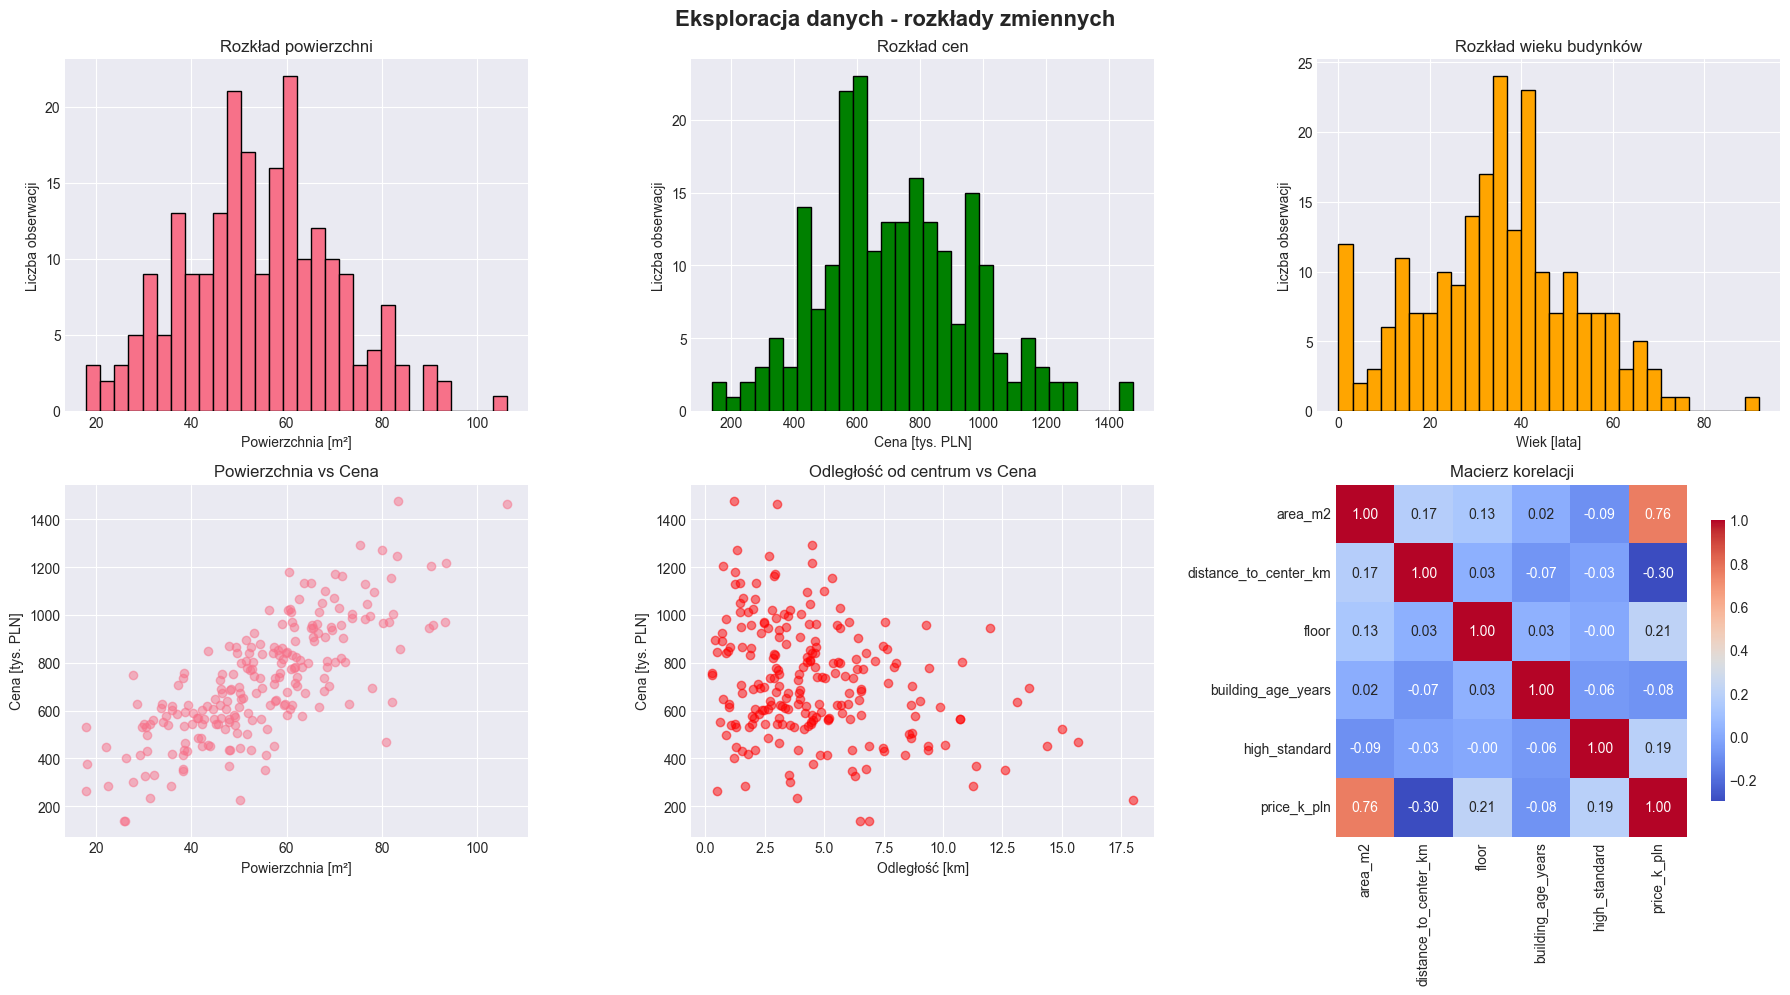

In [107]:
# 7: Wizualizacje eksploracyjne

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Eksploracja danych - rozkłady zmiennych', fontsize=16, fontweight='bold')

df['area_m2'].hist(bins=30, ax=axes[0, 0], edgecolor='black')
axes[0, 0]. set_title('Rozkład powierzchni')
axes[0, 0].set_xlabel('Powierzchnia [m²]')
axes[0, 0].set_ylabel('Liczba obserwacji')

df['price_k_pln'].hist(bins=30, ax=axes[0, 1], edgecolor='black', color='green')
axes[0, 1].set_title('Rozkład cen')
axes[0, 1].set_xlabel('Cena [tys. PLN]')
axes[0, 1].set_ylabel('Liczba obserwacji')

df['building_age_years'].hist(bins=30, ax=axes[0, 2], edgecolor='black', color='orange')
axes[0, 2].set_title('Rozkład wieku budynków')
axes[0, 2].set_xlabel('Wiek [lata]')
axes[0, 2].set_ylabel('Liczba obserwacji')

axes[1, 0].scatter(df['area_m2'], df['price_k_pln'], alpha=0.5)
axes[1, 0]. set_title('Powierzchnia vs Cena')
axes[1, 0].set_xlabel('Powierzchnia [m²]')
axes[1, 0].set_ylabel('Cena [tys. PLN]')

axes[1, 1].scatter(df['distance_to_center_km'], df['price_k_pln'], alpha=0.5, color='red')
axes[1, 1].set_title('Odległość od centrum vs Cena')
axes[1, 1].set_xlabel('Odległość [km]')
axes[1, 1].set_ylabel('Cena [tys. PLN]')

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2], 
            square=True, cbar_kws={'shrink': 0.8})
axes[1, 2].set_title('Macierz korelacji')

plt.tight_layout()
plt.show()


ANALIZA STANDARDU WYKOŃCZENIA

Rozkład standardu wykończenia:
high_standard
0    134
1     86
Name: count, dtype: int64

Udział mieszkań w wysokim standardzie: 39.09%


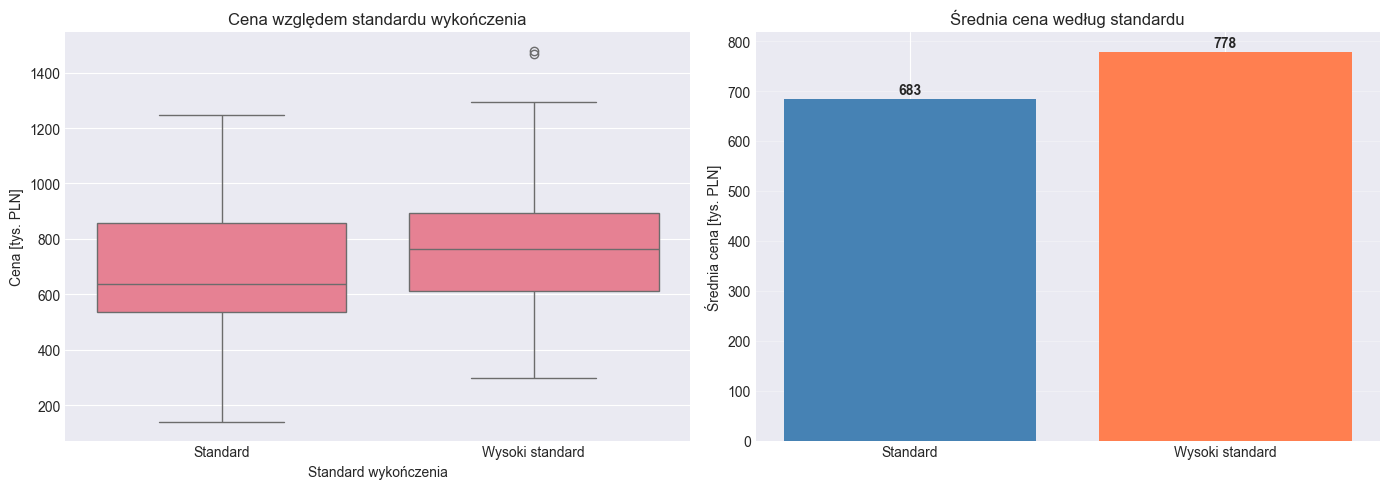


Średnia cena - standard: 683.25 tys. PLN
Średnia cena - wysoki standard: 778.37 tys. PLN
Różnica: 95.12 tys. PLN (13.9%)


In [108]:
# 8: Analiza - standard vs cena

print("\n" + "=" * 80)
print("ANALIZA STANDARDU WYKOŃCZENIA")
print("=" * 80)

print("\nRozkład standardu wykończenia:")
print(df['high_standard'].value_counts())
print(f"\nUdział mieszkań w wysokim standardzie: {(df['high_standard']. sum() / len(df) * 100):.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df.copy()
df_plot['standard'] = df_plot['high_standard'].map({0: 'Standard', 1: 'Wysoki standard'})
sns.boxplot(data=df_plot, x='standard', y='price_k_pln', ax=axes[0])
axes[0].set_title('Cena względem standardu wykończenia')
axes[0].set_xlabel('Standard wykończenia')
axes[0].set_ylabel('Cena [tys. PLN]')

avg_prices = df. groupby('high_standard')['price_k_pln'].mean()
standard_labels = ['Standard', 'Wysoki standard']
axes[1].bar(standard_labels, avg_prices. values, color=['steelblue', 'coral'])
axes[1].set_title('Średnia cena według standardu')
axes[1].set_ylabel('Średnia cena [tys. PLN]')
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(avg_prices.values):
    axes[1].text(i, v + 10, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nŚrednia cena - standard: {avg_prices[0]:.2f} tys. PLN")
print(f"Średnia cena - wysoki standard: {avg_prices[1]:.2f} tys. PLN")
print(f"Różnica: {avg_prices[1] - avg_prices[0]:.2f} tys. PLN ({((avg_prices[1]/avg_prices[0] - 1) * 100):.1f}%)")

In [109]:
# 9: Obsługa braków danych

print("\n" + "=" * 80)
print("PRZYGOTOWANIE DANYCH")
print("=" * 80)

print("\nObsługa braków danych")
braki_przed = df.isnull().sum().sum()
print(f"Braki przed obróbką: {braki_przed}")

if braki_przed > 0:
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isnull().sum() > 0:
            df[col]. fillna(df[col].median(), inplace=True)
            print(f"  - Kolumna '{col}':  imputacja medianą")
    
    braki_po = df.isnull().sum().sum()
    print(f"Braki po obróbce: {braki_po}")
else:
    print("✓ Zbiór nie zawiera brakujących danych")


PRZYGOTOWANIE DANYCH

Obsługa braków danych
Braki przed obróbką: 0
✓ Zbiór nie zawiera brakujących danych


In [110]:
# 10: Podział danych na zbiór treningowy i testowy

print("\nPrzygotowanie zmiennych i podział danych")

X = df.drop('price_k_pln', axis=1)
y = df['price_k_pln']

print(f"Cechy wejściowe (X): {list(X.columns)}")
print(f"Zmienna docelowa (y): price_k_pln")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nPodział danych:")
print(f"Zbiór treningowy: {X_train.shape[0]} obserwacji")
print(f"Zbiór testowy: {X_test.shape[0]} obserwacji")
print(f"Liczba cech: {X_train.shape[1]}")


Przygotowanie zmiennych i podział danych
Cechy wejściowe (X): ['area_m2', 'distance_to_center_km', 'floor', 'building_age_years', 'high_standard']
Zmienna docelowa (y): price_k_pln

Podział danych:
Zbiór treningowy: 176 obserwacji
Zbiór testowy: 44 obserwacji
Liczba cech: 5


In [111]:
# 11: Standaryzacja danych

scaler = StandardScaler()
X_train_scaled = scaler. fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nStandaryzacja wykonana")
print(f"Średnia pierwszej cechy po standaryzacji: {X_train_scaled[: , 0].mean():.4f}")
print(f"Odchylenie std pierwszej cechy: {X_train_scaled[:, 0].std():.4f}")


Standaryzacja wykonana
Średnia pierwszej cechy po standaryzacji: 0.0000
Odchylenie std pierwszej cechy: 1.0000


In [112]:
# 12: Budowa modelu predykcyjnego

print("\n" + "=" * 80)
print("BUDOWA MODELU PREDYKCYJNEGO")
print("=" * 80)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print("\nTrening modelu...")
model.fit(X_train_scaled, y_train)
print("✓ Model wytrenowany pomyślnie")


BUDOWA MODELU PREDYKCYJNEGO

Trening modelu...
✓ Model wytrenowany pomyślnie


In [113]:
# 13: Predykcja

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print("\nPredykcja wykonana dla zbiorów treningowego i testowego")
print(f"\nPrzykładowe predykcje (pierwsze 5):")
print(f"{'Rzeczywiste [tys. PLN]': <25} {'Przewidywane [tys. PLN]':<25} {'Błąd [tys. PLN]': <20}")
print("-" * 70)
for i in range(min(5, len(y_test))):
    real = y_test.values[i]
    pred = y_pred_test[i]
    error = real - pred
    print(f"{real:<25.2f} {pred:<25.2f} {error:<20.2f}")


Predykcja wykonana dla zbiorów treningowego i testowego

Przykładowe predykcje (pierwsze 5):
Rzeczywiste [tys. PLN]    Przewidywane [tys. PLN]   Błąd [tys. PLN]     
----------------------------------------------------------------------
963.30                    854.54                    108.76              
1002.87                   1004.85                   -1.98               
771.84                    812.99                    -41.15              
1096.61                   1095.30                   1.31                
224.41                    494.75                    -270.33             


In [114]:
# 14: Metryki oceny modelu

print("\n" + "=" * 80)
print("OCENA JAKOŚCI MODELU")
print("=" * 80)

mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np. sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"\n{'Metryka':<20} {'Zbiór treningowy':<20} {'Zbiór testowy':<20}")
print("-" * 80)
print(f"{'MSE':<20} {mse_train: <20.2f} {mse_test:<20.2f}")
print(f"{'RMSE':<20} {rmse_train:<20.2f} {rmse_test:<20.2f}")
print(f"{'MAE':<20} {mae_train:<20.2f} {mae_test:<20.2f}")
print(f"{'R²':<20} {r2_train:<20.4f} {r2_test: <20.4f}")
print("-" * 80)

mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
print(f"{'MAPE (test)':<20} {mape_test:<20.2f}%")


OCENA JAKOŚCI MODELU

Metryka              Zbiór treningowy     Zbiór testowy       
--------------------------------------------------------------------------------
MSE                  3066.10              17938.69            
RMSE                 55.37                133.94              
MAE                  42.94                103.89              
R²                   0.9407               0.7872              
--------------------------------------------------------------------------------
MAPE (test)          18.66               %


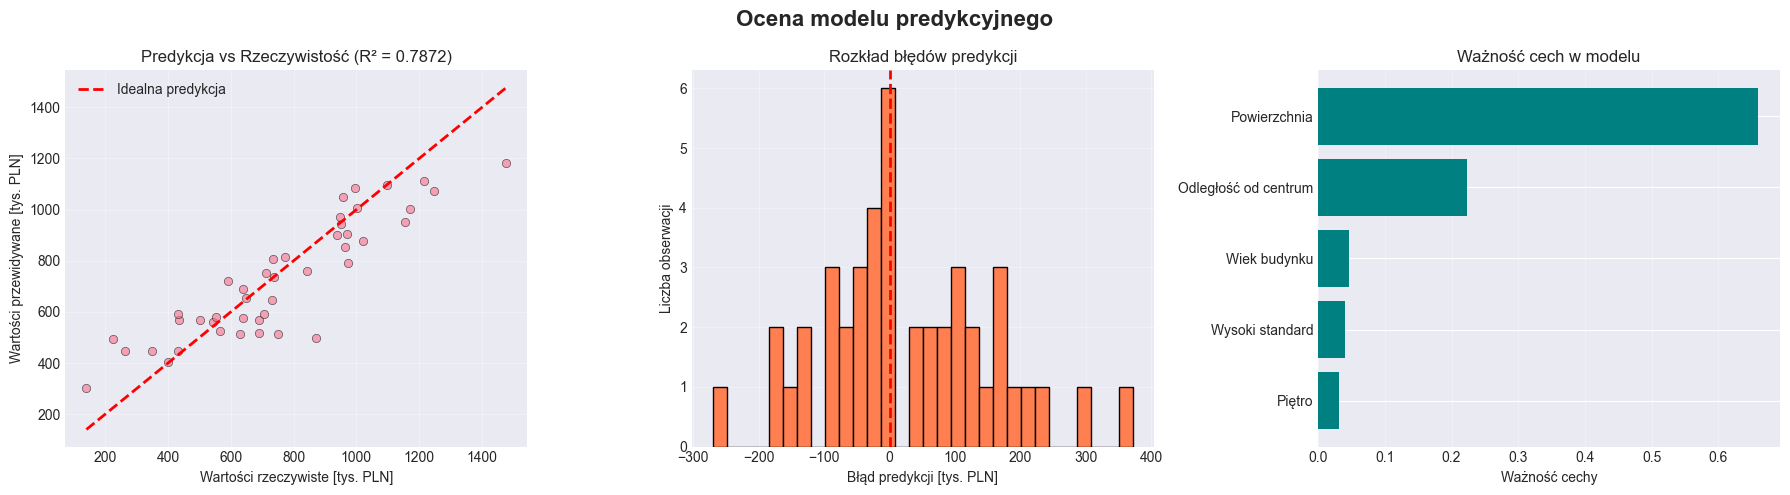

In [115]:
#  15: Wizualizacje wyników

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ocena modelu predykcyjnego', fontsize=16, fontweight='bold')

axes[0].scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Idealna predykcja')
axes[0].set_xlabel('Wartości rzeczywiste [tys. PLN]')
axes[0].set_ylabel('Wartości przewidywane [tys. PLN]')
axes[0].set_title(f'Predykcja vs Rzeczywistość (R² = {r2_test:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_test
axes[1]. hist(residuals, bins=30, edgecolor='black', color='coral')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Błąd predykcji [tys. PLN]')
axes[1].set_ylabel('Liczba obserwacji')
axes[1].set_title('Rozkład błędów predykcji')
axes[1].grid(True, alpha=0.3)

feature_importance = pd.DataFrame({
    'feature': X. columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

feature_labels = {
    'area_m2':  'Powierzchnia',
    'distance_to_center_km': 'Odległość od centrum',
    'floor':  'Piętro',
    'building_age_years': 'Wiek budynku',
    'high_standard': 'Wysoki standard'
}
feature_importance['feature_pl'] = feature_importance['feature'].map(feature_labels)

axes[2].barh(feature_importance['feature_pl'], feature_importance['importance'], color='teal')
axes[2].set_xlabel('Ważność cechy')
axes[2].set_title('Ważność cech w modelu')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


ANALIZA SZCZEGÓŁOWA WYNIKÓW

Ważność cech:
  Powierzchnia              0.6593 (65.93%)
  Odległość od centrum      0.2227 (22.27%)
  Wiek budynku              0.0469 (4.69%)
  Wysoki standard           0.0399 (3.99%)
  Piętro                    0.0312 (3.12%)

STATYSTYKI BŁĘDÓW

Błąd minimalny:          1.31 tys. PLN
Błąd maksymalny:       371.80 tys. PLN
Błąd medianowy:        91.26 tys. PLN
Błąd średni (MAE):     103.89 tys. PLN
RMSE:                   133.94 tys. PLN
Średni procent błędu:  18.66%


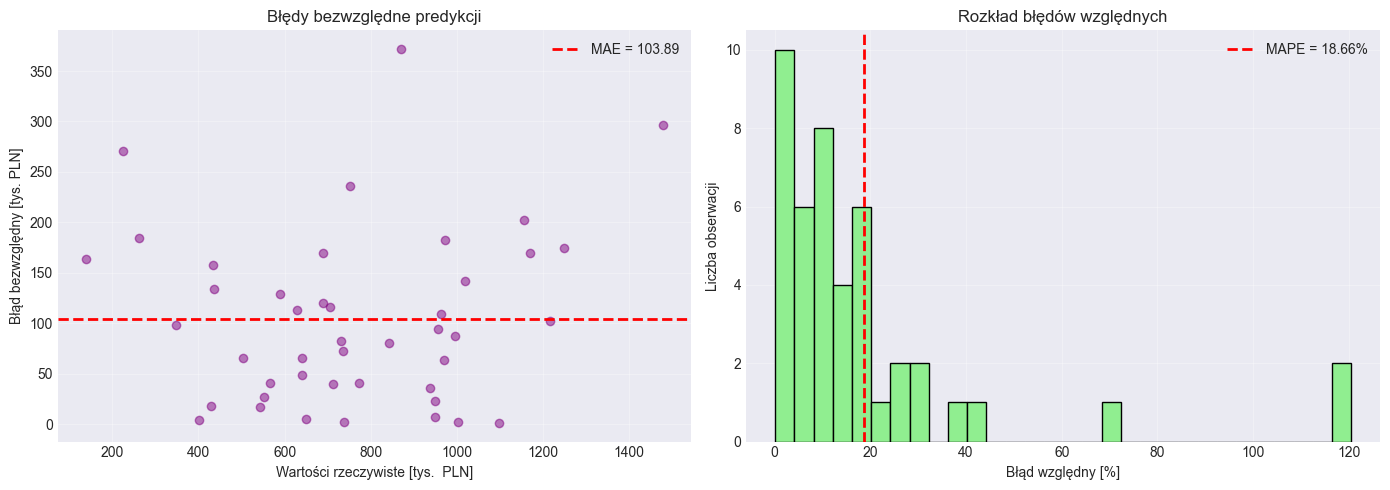

In [116]:
# 16: Analiza szczegółowa

print("\n" + "=" * 80)
print("ANALIZA SZCZEGÓŁOWA WYNIKÓW")
print("=" * 80)

print("\nWażność cech:")
feature_importance_sorted = feature_importance.sort_values('importance', ascending=False)
for idx, row in feature_importance_sorted.iterrows():
    print(f"  {row['feature_pl']: <25} {row['importance']:.4f} ({row['importance']*100:.2f}%)")

print("\n" + "=" * 80)
print("STATYSTYKI BŁĘDÓW")
print("=" * 80)

abs_errors = np.abs(residuals)
print(f"\nBłąd minimalny:          {abs_errors.min():.2f} tys. PLN")
print(f"Błąd maksymalny:       {abs_errors.max():.2f} tys. PLN")
print(f"Błąd medianowy:        {abs_errors. median():.2f} tys. PLN")
print(f"Błąd średni (MAE):     {mae_test:.2f} tys. PLN")
print(f"RMSE:                   {rmse_test:.2f} tys. PLN")
print(f"Średni procent błędu:  {mape_test:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, abs_errors, alpha=0.5, color='purple')
axes[0].axhline(y=mae_test, color='red', linestyle='--', linewidth=2, label=f'MAE = {mae_test:.2f}')
axes[0].set_xlabel('Wartości rzeczywiste [tys.  PLN]')
axes[0].set_ylabel('Błąd bezwzględny [tys. PLN]')
axes[0].set_title('Błędy bezwzględne predykcji')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

pct_errors = np.abs((y_test - y_pred_test) / y_test) * 100
axes[1].hist(pct_errors, bins=30, edgecolor='black', color='lightgreen')
axes[1].axvline(x=mape_test, color='red', linestyle='--', linewidth=2, label=f'MAPE = {mape_test:.2f}%')
axes[1].set_xlabel('Błąd względny [%]')
axes[1].set_ylabel('Liczba obserwacji')
axes[1].set_title('Rozkład błędów względnych')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [117]:
# 17: Wnioski

print("\n" + "=" * 80)
print("WNIOSKI")
print("=" * 80)

print("\n6.1 JAKOŚĆ MODELU")
if r2_test > 0.85:
    quality = "bardzo dobra"
elif r2_test > 0.7:
    quality = "dobra"
elif r2_test > 0.5:
    quality = "zadowalająca"
else:
    quality = "niezadowalająca"

print(f"- Model wykazuje {quality} zdolność predykcyjną (R² = {r2_test:.4f})")
print(f"- Model wyjaśnia {r2_test*100:.2f}% wariancji cen nieruchomości")
print(f"- Średni błąd bezwzględny wynosi {mae_test:.2f} tys. PLN")
print(f"- Średni procent błędu (MAPE) wynosi {mape_test:.2f}%")
print(f"- RMSE na poziomie {rmse_test:.2f} tys. PLN wskazuje na stabilność predykcji")

overfitting_gap = r2_train - r2_test
if overfitting_gap < 0.05:
    print(f"- Model nie wykazuje przeuczenia (różnica R²: {overfitting_gap:.4f})")
elif overfitting_gap < 0.15:
    print(f"- Wykryto minimalne przeuczenie (różnica R²: {overfitting_gap:.4f})")
else:
    print(f"- Model jest przeuczony (różnica R²: {overfitting_gap:.4f})")

print("\n6.2 KLUCZOWE CZYNNIKI WPŁYWAJĄCE NA CENĘ")
print("Ranking najważniejszych cech:")
for i, row in enumerate(feature_importance_sorted.iterrows(), 1):
    print(f"{i}. {row[1]['feature_pl']} - {row[1]['importance']*100:.2f}%")

print("\n6.3 PRZYDATNOŚĆ PRAKTYCZNA")
print("- Model nadaje się do wstępnej wyceny nieruchomości")
print("- Może wspierać decyzje inwestycyjne i biznesowe")
print("- Identyfikuje kluczowe czynniki wpływające na cenę")
print("- Może służyć do wykrywania nieruchomości niedowartościowanych/przewartościowanych")
print(f"- Średni błąd {mape_test:.1f}% jest akceptowalny dla szacunków wstępnych")

print("\n6.4 OGRANICZENIA")
print("- Model nie uwzględnia czynników jakościowych trudnych do zmierzenia")
print("- Brak danych o najbliższym sąsiedztwie i infrastrukturze")
print("- Predykcje poza zakresem danych treningowych mogą być mniej dokładne")
print("- Nie uwzględnia trendów czasowych i sezonowości rynku")
print("- Brak informacji o stanie technicznym poza wiekiem i standardem")

print("\n6.5 REKOMENDACJE ROZWOJU")
print("- Wzbogacenie zbioru o dane geolokalizacyjne (współrzędne GPS)")
print("- Dodanie informacji o infrastrukturze (szkoły, transport, sklepy)")
print("- Uwzględnienie trendów czasowych i czynników makroekonomicznych")
print("- Testowanie zaawansowanych modeli (XGBoost, LightGBM, CatBoost)")
print("- Implementacja walidacji krzyżowej dla lepszej oceny stabilności")
print("- Analiza i obsługa wartości odstających (outliers)")
print("- Dodanie cech interakcyjnych (np. powierzchnia × standard)")
print("- Implementacja interpretacji modelu (SHAP values)")


WNIOSKI

6.1 JAKOŚĆ MODELU
- Model wykazuje dobra zdolność predykcyjną (R² = 0.7872)
- Model wyjaśnia 78.72% wariancji cen nieruchomości
- Średni błąd bezwzględny wynosi 103.89 tys. PLN
- Średni procent błędu (MAPE) wynosi 18.66%
- RMSE na poziomie 133.94 tys. PLN wskazuje na stabilność predykcji
- Model jest przeuczony (różnica R²: 0.1534)

6.2 KLUCZOWE CZYNNIKI WPŁYWAJĄCE NA CENĘ
Ranking najważniejszych cech:
1. Powierzchnia - 65.93%
2. Odległość od centrum - 22.27%
3. Wiek budynku - 4.69%
4. Wysoki standard - 3.99%
5. Piętro - 3.12%

6.3 PRZYDATNOŚĆ PRAKTYCZNA
- Model nadaje się do wstępnej wyceny nieruchomości
- Może wspierać decyzje inwestycyjne i biznesowe
- Identyfikuje kluczowe czynniki wpływające na cenę
- Może służyć do wykrywania nieruchomości niedowartościowanych/przewartościowanych
- Średni błąd 18.7% jest akceptowalny dla szacunków wstępnych

6.4 OGRANICZENIA
- Model nie uwzględnia czynników jakościowych trudnych do zmierzenia
- Brak danych o najbliższym sąsiedztwie i in